In [1]:
# load .env file
from dotenv import load_dotenv
load_dotenv()

True

/Users/sulbhajain/Documents/Personal/genAI_projects/langgraph_agents/lang_env/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


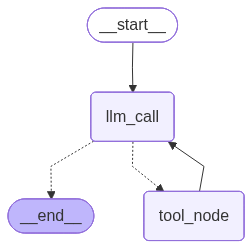

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================

[{'id': 'toolu_01FwvwrWZxykipvzUtbaMcAZ', 'input': {'a': 3, 'b': 4}, 'name': 'add', 'type': 'tool_use'}]
Tool Calls:
  add (toolu_01FwvwrWZxykipvzUtbaMcAZ)
 Call ID: toolu_01FwvwrWZxykipvzUtbaMcAZ
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.


In [2]:
# Step 1: Define tools and model

from langchain.tools import tool
from langchain.chat_models import init_chat_model


model = init_chat_model(
    "claude-sonnet-4-5-20250929",
    temperature=0
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

# Step 2: Define state

from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

# Step 3: Define model node
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }


# Step 4: Define tool node

from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

# Step 5: Define logic to determine whether to end

from typing import Literal
from langgraph.graph import StateGraph, START, END


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

# Step 6: Build agent

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()


from IPython.display import Image, display
# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

In [3]:
from langchain.agents import create_agent
from langchain.messages import SystemMessage, HumanMessage

literary_agent = create_agent(
    model="anthropic:claude-sonnet-4-5",
    system_prompt=SystemMessage(
        content=[
            {
                "type": "text",
                "text": "You are an AI assistant tasked with analyzing literary works.",
            },
            {
                "type": "text",
                "text": "<the entire contents of 'Pride and Prejudice'>",
                "cache_control": {"type": "ephemeral"}
            }
        ]
    )
)

result = literary_agent.invoke(
    {"messages": [HumanMessage("Analyze the major themes in 'Pride and Prejudice'.")]}
)
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

# Major Themes in 'Pride and Prejudice'

Jane Austen's "Pride and Prejudice" explores several interconnected themes:

## 1. **Pride and Prejudice**
The title itself highlights the central theme. Elizabeth's prejudice against Darcy and his pride in his social position create the main conflict. Both characters must overcome these flaws to find happiness together.

## 2. **Class and Social Standing**
The novel critically examines the rigid class structure of Regency England. Marriage is often viewed as a means of social advancement, and characters are judged by their wealth and connections rather than personal merit.

## 3. **Marriage and Love**
Austen presents various marriage models:
- Charlotte's pragmatic marriage to Mr. Collins
- Lydia's reckless elopement
- Jane and Bingley's genuine affection
- Elizabeth and Darcy's union based on mutual respect and love

The novel advocates for marriages founded on c

In [ ]:
from typing import TypedDict

from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest

@tool("web_search")  # Custom name
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"

print(search.name)  # web_search

class Context(TypedDict):
    user_role: str

@dynamic_prompt
def user_role_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user role."""
    user_role = request.runtime.context.get("user_role", "user")
    base_prompt = "You are a helpful assistant."

    if user_role == "expert":
        return f"{base_prompt} Provide detailed technical responses."
    elif user_role == "beginner":
        return f"{base_prompt} Explain concepts simply and avoid jargon."

    return base_prompt

agent = create_agent(
    model="gpt-4o",
    tools=[search],
    middleware=[user_role_prompt],
    context_schema=Context
)

# The system prompt will be set dynamically based on context
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Explain machine learning"}]},
    context={"user_role": "expert"}
)
print (result["messages"][-1].content)  # Detailed technical response

web_search


Machine learning is a subset of artificial intelligence (AI) that enables systems to learn and make decisions or predictions based on data. It is centered around the idea that systems can automatically learn from data, identify patterns, and improve from experience without being explicitly programmed. Here are some key aspects and concepts of machine learning:

### 1. **Types of Machine Learning**
- **Supervised Learning**: In this type, the model is trained on a labeled dataset, which means that each training example is paired with an output label. The system makes predictions and is corrected by the dataset. Examples include regression and classification tasks.
  
- **Unsupervised Learning**: The model is given data without explicit instructions on what to do with it. It tries to find patterns and relationships. Common methods include clustering and association analysis.
  
- **Semi-supervised Learning**: This combines both labeled and unlabeled data for training – typically a small 

In [6]:
from dataclasses import dataclass
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime


USER_DATABASE = {
    "user123": {
        "name": "Alice Johnson",
        "account_type": "Premium",
        "balance": 5000,
        "email": "alice@example.com"
    },
    "user456": {
        "name": "Bob Smith",
        "account_type": "Standard",
        "balance": 1200,
        "email": "bob@example.com"
    }
}

@dataclass
class UserContext:
    user_id: str

@tool
def get_account_info(runtime: ToolRuntime[UserContext]) -> str:
    """Get the current user's account information."""
    user_id = runtime.context.user_id

    if user_id in USER_DATABASE:
        user = USER_DATABASE[user_id]
        return f"Account holder: {user['name']}\nType: {user['account_type']}\nBalance: ${user['balance']}"
    return "User not found"

model = ChatOpenAI(model="gpt-4o")
agent = create_agent(
    model,
    tools=[get_account_info],
    context_schema=UserContext,
    system_prompt="You are a financial assistant."
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's my current balance?"}]},
    context=UserContext(user_id="user123")
)
print(result["messages"][-1].content)  # Should include Alice Johnson's balance information

Your current balance is $5,000.


In [7]:
from typing import Any
from langgraph.store.memory import InMemoryStore
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime


# Access memory
@tool
def get_user_info(user_id: str, runtime: ToolRuntime) -> str:
    """Look up user info."""
    store = runtime.store
    user_info = store.get(("users",), user_id)
    return str(user_info.value) if user_info else "Unknown user"

# Update memory
@tool
def save_user_info(user_id: str, user_info: dict[str, Any], runtime: ToolRuntime) -> str:
    """Save user info."""
    store = runtime.store
    store.put(("users",), user_id, user_info)
    return "Successfully saved user info."

store = InMemoryStore()
agent = create_agent(
    model,
    tools=[get_user_info, save_user_info],
    store=store
)

# First session: save user info
agent.invoke({
    "messages": [{"role": "user", "content": "Save the following user: userid: abc123, name: Foo, age: 25, email: foo@langchain.dev"}]
})

# Second session: get user info
agent.invoke({
    "messages": [{"role": "user", "content": "Get user info for user with id 'abc123'"}]
})
# Here is the user info for user with ID "abc123":
# - Name: Foo
# - Age: 25
# - Email: foo@langchain.dev

{'messages': [HumanMessage(content="Get user info for user with id 'abc123'", additional_kwargs={}, response_metadata={}, id='1861652e-20e6-482c-9a29-0f8580e45b7e'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 75, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-CsFU80mlv7FfkLKCD1L0DlSRRQIMs', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b6c1b-14f4-7021-8c4f-698e4c5b5b67-0', tool_calls=[{'name': 'get_user_info', 'args': {'user_id': 'abc123'}, 'id': 'call_yUYvtXeZ5z1ed6YAUtCLaHKq', 'type': 'tool_call'}], usage_metadata={'input_tokens': 75, 'output_tokens': 17

### trim messages

In [8]:
from langchain.messages import RemoveMessage
from langgraph.graph.message import REMOVE_ALL_MESSAGES
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent, AgentState
from langchain.agents.middleware import before_model
from langgraph.runtime import Runtime
from langchain_core.runnables import RunnableConfig
from typing import Any


@before_model
def trim_messages(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Keep only the last few messages to fit context window."""
    messages = state["messages"]

    if len(messages) <= 3:
        return None  # No changes needed

    first_msg = messages[0]
    recent_messages = messages[-3:] if len(messages) % 2 == 0 else messages[-4:]
    new_messages = [first_msg] + recent_messages

    return {
        "messages": [
            RemoveMessage(id=REMOVE_ALL_MESSAGES),
            *new_messages
        ]
    }

model = ChatOpenAI(model="gpt-4o-mini")
agent = create_agent(
    model,
    # tools=your_tools_here,
    middleware=[trim_messages],
    checkpointer=InMemorySaver(),
)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}

agent.invoke({"messages": "hi, my name is bob"}, config)
agent.invoke({"messages": "write a short poem about cats"}, config)
agent.invoke({"messages": "now do the same but for dogs"}, config)
final_response = agent.invoke({"messages": "what's my name?"}, config)

final_response["messages"][-1].pretty_print()
"""
================================== Ai Message ==================================

Your name is Bob. You told me that earlier.
If you'd like me to call you a nickname or use a different name, just say the word.
"""

================================== Ai Message ==================================

Your name is Bob. How can I assist you today, Bob?


"\n================================== Ai Message ==================================\n\nYour name is Bob. You told me that earlier.\nIf you'd like me to call you a nickname or use a different name, just say the word.\n"

In [10]:
final_response = agent.invoke({"messages": "do you really know my name?"}, config)
final_response["messages"][-1].pretty_print()

================================== Ai Message ==================================

Yes, you mentioned that your name is Bob in our previous messages. I don't have any personal information about you beyond what you share in our conversation. How can I help you today?


In [11]:
from langchain.messages import RemoveMessage
from langchain.agents import create_agent, AgentState
from langchain.agents.middleware import after_model
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.runtime import Runtime
from langchain_core.runnables import RunnableConfig


@after_model
def delete_old_messages(state: AgentState, runtime: Runtime) -> dict | None:
    """Remove old messages to keep conversation manageable."""
    messages = state["messages"]
    if len(messages) > 2:
        # remove the earliest two messages
        return {"messages": [RemoveMessage(id=m.id) for m in messages[:2]]}
    return None


agent = create_agent(
    "gpt-5-nano",
    tools=[],
    system_prompt="Please be concise and to the point.",
    middleware=[delete_old_messages],
    checkpointer=InMemorySaver(),
)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}

for event in agent.stream(
    {"messages": [{"role": "user", "content": "hi! I'm bob"}]},
    config,
    stream_mode="values",
):
    print([(message.type, message.content) for message in event["messages"]])

for event in agent.stream(
    {"messages": [{"role": "user", "content": "what's my name?"}]},
    config,
    stream_mode="values",
):
    print([(message.type, message.content) for message in event["messages"]])

[('human', "hi! I'm bob")]
[('human', "hi! I'm bob"), ('ai', 'Nice to meet you, Bob! What can I help you with today? I can answer questions, brainstorm ideas, draft text, explain topics, or assist with coding. Tell me what you’re working on.')]
[('human', "hi! I'm bob"), ('ai', 'Nice to meet you, Bob! What can I help you with today? I can answer questions, brainstorm ideas, draft text, explain topics, or assist with coding. Tell me what you’re working on.'), ('human', "what's my name?")]
[('human', "hi! I'm bob"), ('ai', 'Nice to meet you, Bob! What can I help you with today? I can answer questions, brainstorm ideas, draft text, explain topics, or assist with coding. Tell me what you’re working on.'), ('human', "what's my name?"), ('ai', 'Your name is Bob. If you’d like, I can call you something else or remember this for our chat.')]
[('human', "what's my name?"), ('ai', 'Your name is Bob. If you’d like, I can call you something else or remember this for our chat.')]


In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig


checkpointer = InMemorySaver()

agent = create_agent(
    model="gpt-4o",
    tools=[],
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("tokens", 4000),
            keep=("messages", 20)
        )
    ],
    checkpointer=checkpointer,
)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}
agent.invoke({"messages": "hi, my name is bob"}, config)
agent.invoke({"messages": "write a short poem about cats"}, config)
agent.invoke({"messages": "now do the same but for dogs"}, config)
final_response = agent.invoke({"messages": "what's my name?"}, config)

final_response["messages"][-1].pretty_print()
"""
================================== Ai Message ==================================

Your name is Bob!
"""

================================== Ai Message ==================================

Your name is Bob.


'\n================================== Ai Message ==================================\n\nYour name is Bob!\n'

## Guardrails

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware


agent = create_agent(
    model="gpt-4o",
    # tools=[customer_service_tool, email_tool],
    middleware=[
        # Redact emails in user input before sending to model
        PIIMiddleware(
            "email",
            strategy="redact",
            apply_to_input=True,
        ),
        # Mask credit cards in user input
        PIIMiddleware(
            "credit_card",
            strategy="mask",
            apply_to_input=True,
        ),
        # Block API keys - raise error if detected
        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-Z0-9]{32}",
            strategy="block",
            apply_to_input=True,
        ),
    ],
)

# When user provides PII, it will be handled according to the strategy
result = agent.invoke({
    "messages": [{"role": "user", "content": "My email is john.doe@example.com and card is 5105-1051-0510-5100"}]
})
result["messages"][-1].pretty_print()

In [14]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

I'm sorry, I can't assist with that request.
